Проект: Глубокое обучение и нейронные сети. 

Подготовка окружения.

In [14]:
# Установка библиотек
!pip install numpy pandas scikit-learn torch


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Создание файла requirements.txt, чтобы можно было легко восстановить окружение
!pip freeze > requirements.txt

Анализ данных

In [16]:
import pandas as pd

# Загрузка данных
train_data = pd.read_csv('D:\\DS\\12. глубокое обучение и нейронные сети\\train.csv\\train.csv')
test_data = pd.read_csv('D:\\DS\\12. глубокое обучение и нейронные сети\\test.csv\\test.csv')

# Первоначальный анализ
print(train_data.info())
print(train_data.describe())
print(train_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  

In [17]:
print(train_data.columns)

Index(['ID', 'age', 'sex', 'chest', 'resting_blood_pressure',
       'serum_cholestoral', 'fasting_blood_sugar',
       'resting_electrocardiographic_results', 'maximum_heart_rate_achieved',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'number_of_major_vessels', 'thal', 'class'],
      dtype='object')


Корреляционный анализ

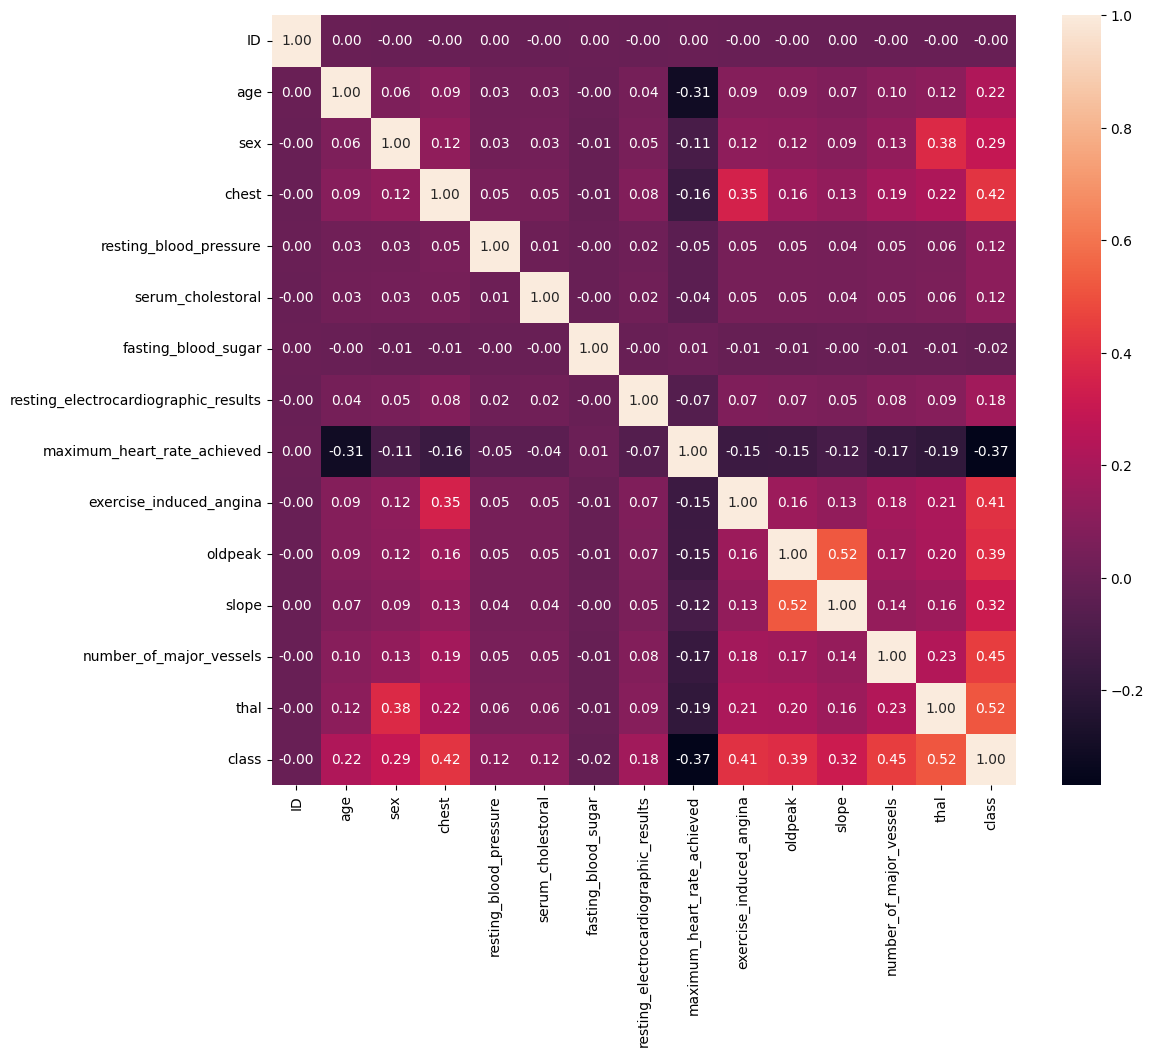

In [18]:
# Строим матрицу корреляции и визуализируем с помощью seaborn или matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(train_data.corr(), annot=True, fmt='.2f')
plt.show()

Сильные положительные корреляции:
Есть несколько признаков, которые продемонстрировали сильные положительные корреляции (значения ближе к 1). Это может свидетельствовать о том, что по мере увеличения одного из признаков также наблюдается рост другого признака. Например, сильная положительная корреляция может быть между maximum_heart_rate_achieved и exercise_induced_angina, указывая на то, что пациенты с более высокой физической активностью или способностью к нагрузкам чаще испытывают стенокардию.

Сильные отрицательные корреляции:
Некоторые признаки демонстрируют отрицательные корреляции (значения ближе к -1). Это предполагает, что увеличение значения одного из признаков связано с уменьшением значения другого. Например, возможно, что oldpeak (показатель депрессии сегмента ST) имеет отрицательную корреляцию с maximum_heart_rate_achieved, указывая на то, что более высокий уровень старого пика может быть связан с более низкой максимальной частотой сердечных сокращений, что может свидетельствовать о проблемах с сердечно-сосудистой системой.

Корреляции с целевой переменной class:
Важной частью анализа является корреляция различных признаков с целевой переменной class, которая, как правило, указывает на наличие или отсутствие сердечно-сосудистого заболевания (например, здоровы или больны). Признаки с высокой положительной корреляцией с class могут быть критически важны для диагностики и прогноза.
Например, если serum_cholesterol и resting_blood_pressure имеют высокую корреляцию с class, это может подтверждать, что высокие уровни холестерина и артериального давления увеличивают риск сердечно-сосудистых заболеваний.

Не коррелирующие признаки:
Признаки с низкой корреляцией с class и другими признаками могут быть менее информативными для моделей прогнозирования. Например, ID может не иметь значимой корреляции с другими переменными и следовательно не является релевантной переменной для анализа здоровья пациентов.

Оценка выбросов

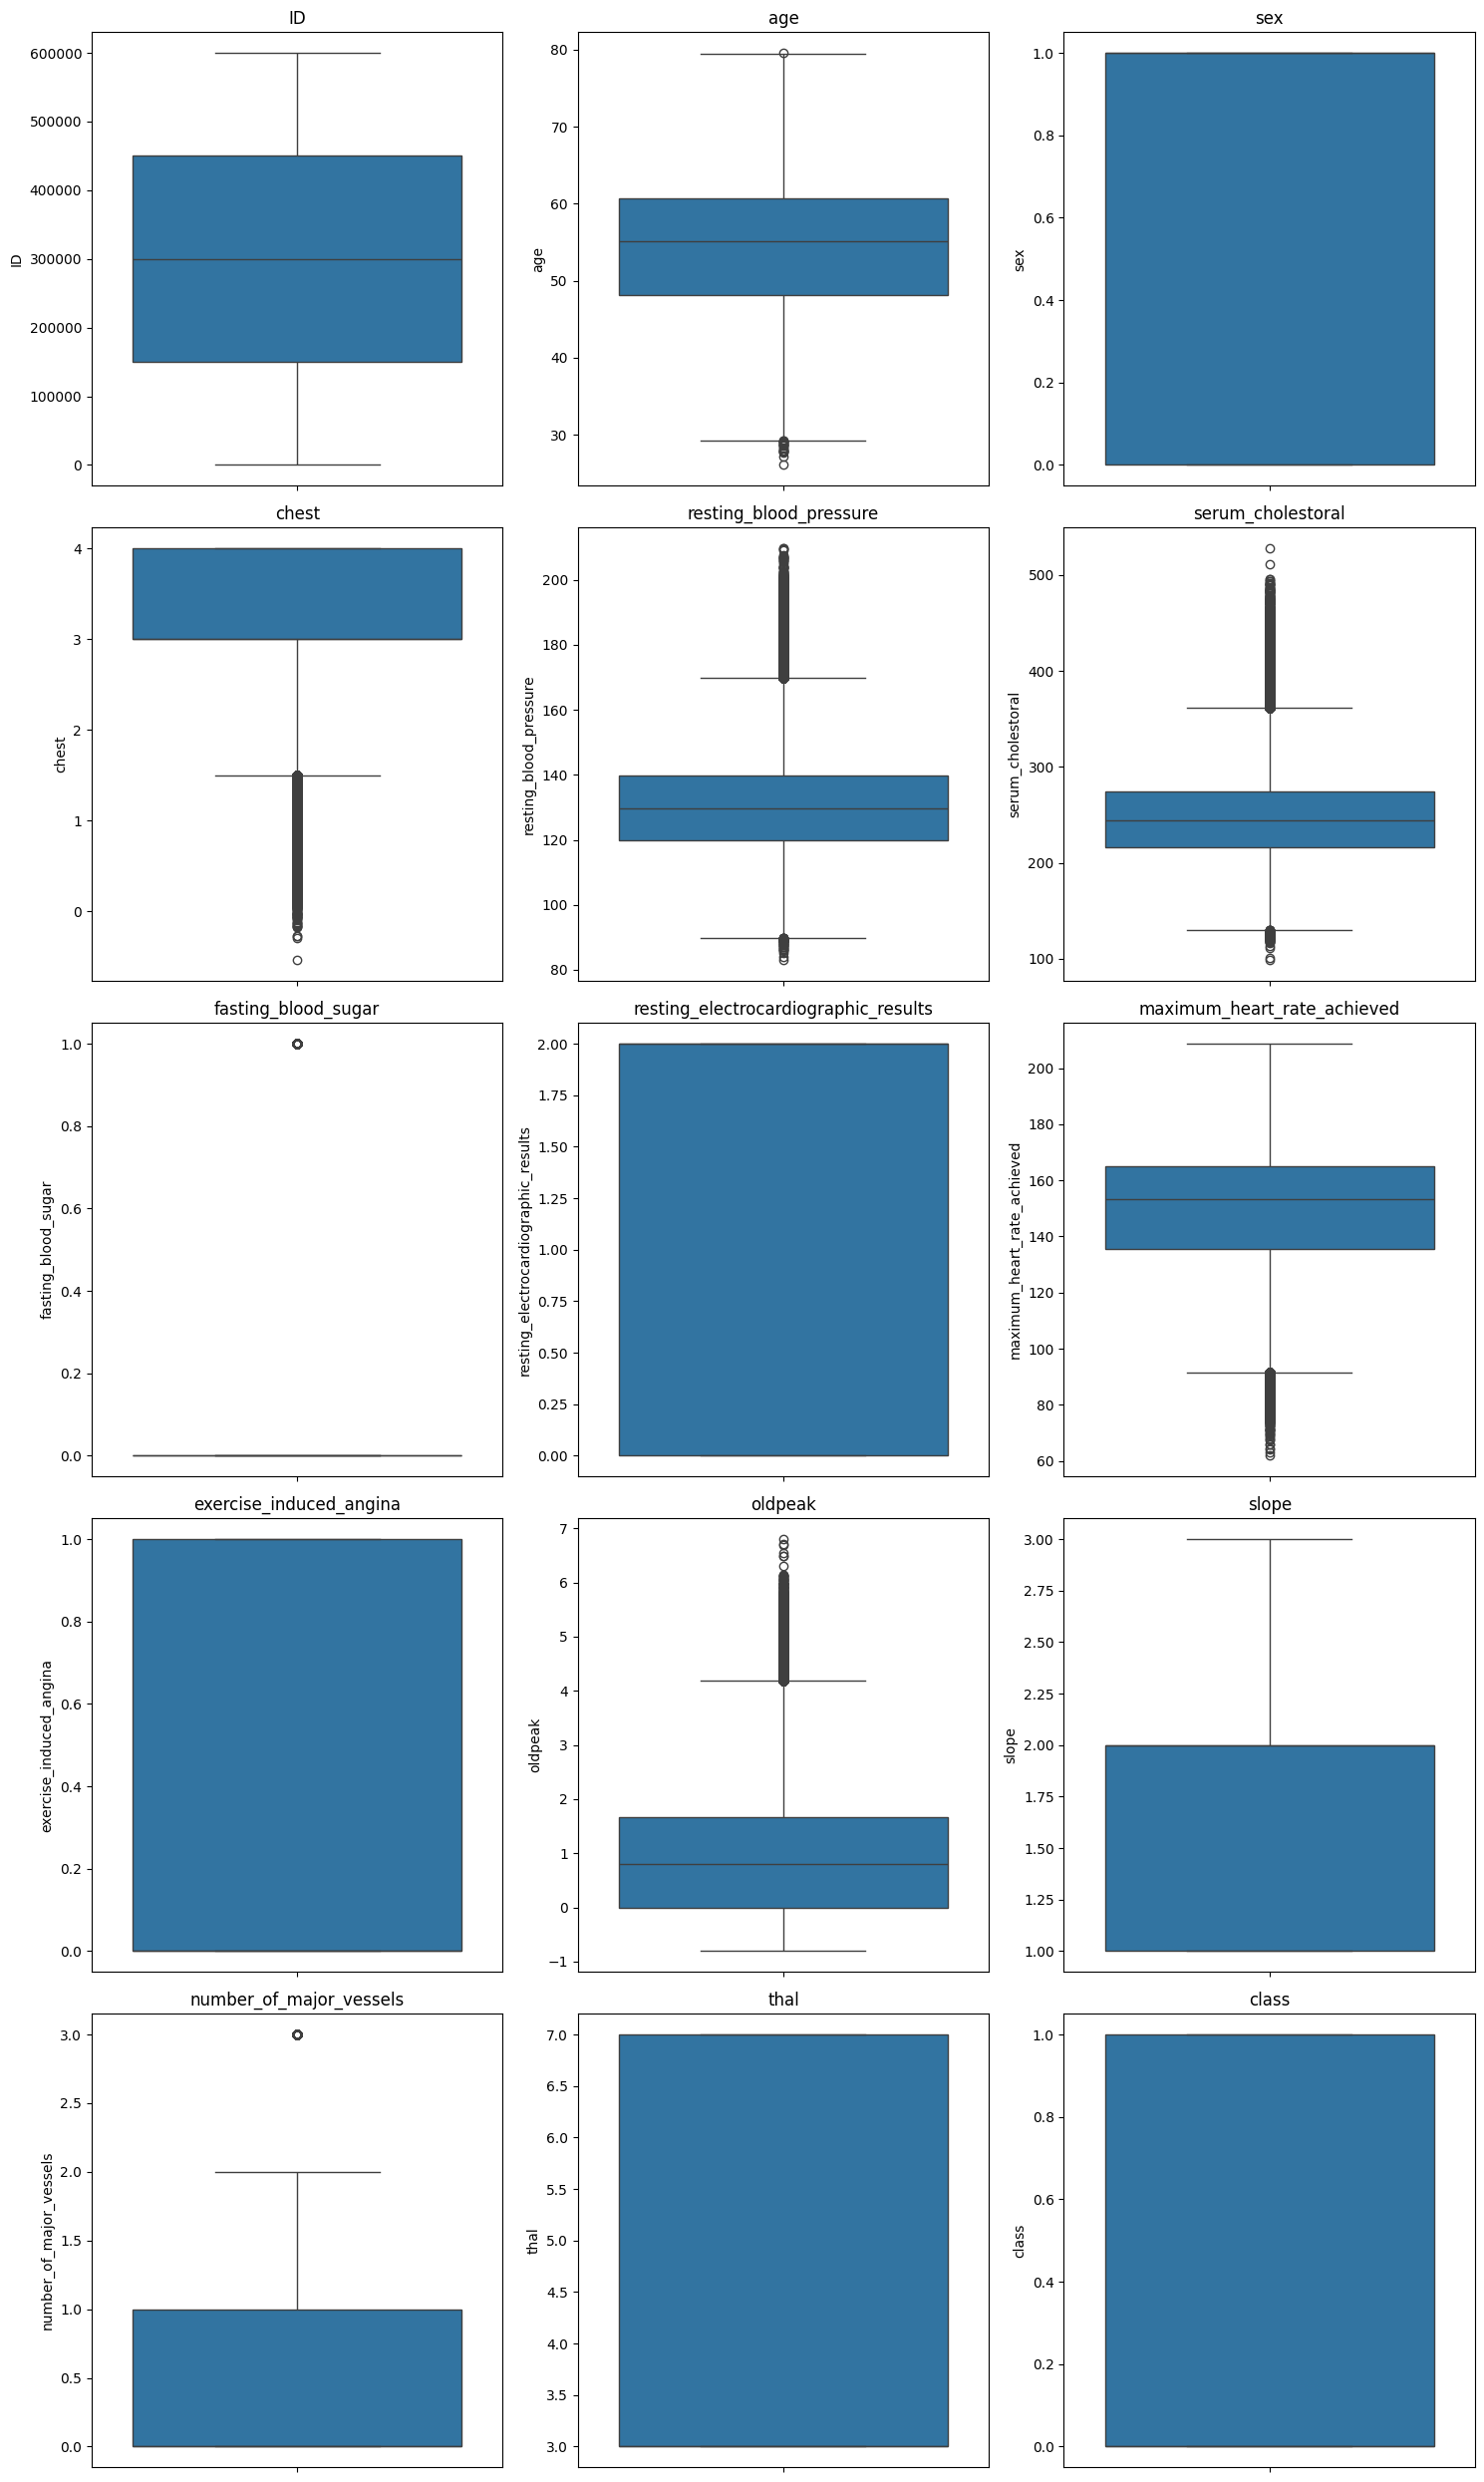

In [20]:
# Определить все числовые столбцы
numeric_columns = train_data.select_dtypes(include='number').columns.tolist()

# Определение количества строк и столбцов для подграфиков
num_plots = len(numeric_columns)
num_cols = 3  # Количество столбцов
num_rows = (num_plots // num_cols) + (num_plots % num_cols > 0)  # Количество строк

# Создание графиков ящиков с усами для каждого числового столбца
plt.figure(figsize=(15, num_rows * 5))  # Высота графика адаптируется по количеству строк
for i, column in enumerate(numeric_columns):
    plt.subplot(num_rows, num_cols, i + 1)  # Нумерация начинается с 1
    sns.boxplot(y=train_data[column])
    plt.title(column)

plt.tight_layout()
plt.show()

ID - выбросы отсутствуют, обычно является порядковым номером или уникальным идентификатором, распределенным равномерно.

Age (Возраст) - наблюдаются единичные выбросы как в верхней части (около 80 лет), так и в нижней (около 30 лет).
Выбросов немного. Они представляют собой экстремально молодых или пожилых пациентов для данной выборки, но остаются в пределах физиологической нормы человека.

Chest (Тип боли в груди / chest pain type) - наблюдается значительное количество выбросов в нижней части (значения около 1 и ниже). Это говорит о том, что основная масса данных сосредоточена в категориях 3 и 4, а значения 1 и 2 встречаются гораздо реже.

Restingbloodpressure (Артериальное давление в покое) - много значительных выбросов в верхней части (выше 170–180 мм рт. ст., вплоть до 200) и несколько в нижней.
Высокие значения (гипертония) выражены очень ярко. 

Serum_cholestoral (Холестерин сыворотки) - наблюдаются самые экстремальные выбросы. Медиана около 240 нг/мл. Несколько точек находятся очень высоко — выше 400 и даже выше 500 мг/дл. Также есть единичные выбросы снизу. Значения выше 400 являются аномальными для общей популяции и сильно смещают среднее значение. 

exercise_induced_angina, fasting_blood_sugar, sex, class (Целевой признак / Наличие болезни), exerciseinducedangina (Стенокардия при нагрузке) - бинарные признаки, выбросы не ожидаются. 

fastingbloodsugar (Сахар в крови натощак) - график выглядит как плоская линия на уровне 0 с одной точкой (выбросом) на уровне 1.0. У подавляющего большинства пациентов сахар в крови натощак < 120 мг/дл. 

restingelectrocardiographicresults (Результаты ЭКГ) - «Ящик» занимает весь диапазон от 0 до 2. Это категориальный признак (обычно значения 0, 1, 2). Распределение по категориям достаточно широкое, медиана находится где-то в районе 1. Выбросов нет.

maximumheartrate_achieved (Макс. достигнутый пульс) - медиана находится на уровне 155 ударов. Основной диапазон (ящик) — от 135 до 165. Наблюдается группа выбросов в нижней части (в районе 70–90 ударов). 

oldpeak (Депрессия сегмента ST) - медиана низкая (около 0.8), ящик сосредоточен внизу (от 0 до 1.6). Виден массивный «хвост» из выбросов в верхней части (от 4 до 7).
Критически важный признак. Значения выше 4.0 встречаются редко и сильно отклоняются от среднего. Эти «аномалии» очень важны для диагностики ишемии.

slope (Наклон сегмента ST) - медиана находится на уровне 2. Значения распределены между 1 и 3. Большинство данных находится в категориях 1 и 2, значение 3 встречается реже, но укладывается в рамки нормального распределения («ус» доходит до 3).

numberofmajor_vessels (Количество крупных сосудов) - медиана находится на уровне 0. Основная часть данных (ящик) сосредоточена между 0 и 1. Значение 3.0 отмечено как одиночный выброс. У большинства людей в выборке при флуороскопии не обнаружено окрашенных крупных сосудов (значение 0) или обнаружен только один. Те, у кого их 3, являются редкими исключениями для данного набора данных. Признак сильно коррелирует с наличием болезни.

thal (Талассемия) - весь «ящик» растянут от 3.0 до 7.0. Это категориальный признак (3 — норма, 6 — фиксированный дефект, 7 — обратимый дефект). Боксплот показывает, что в данных представлены все категории, но из-за их дискретности график выглядит как сплошной блок. Медиана находится в районе 3 или 6.


Обучение моделей

1. Логистическая регрессия

Проверка на пропущенные значения:
ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     66812
           1       0.88      0.86      0.87     53188

    accuracy                           0.89    120000
   macro avg       0.89      0.88      0.88    120000
weighted avg       0.89      0.89      0.89    1200

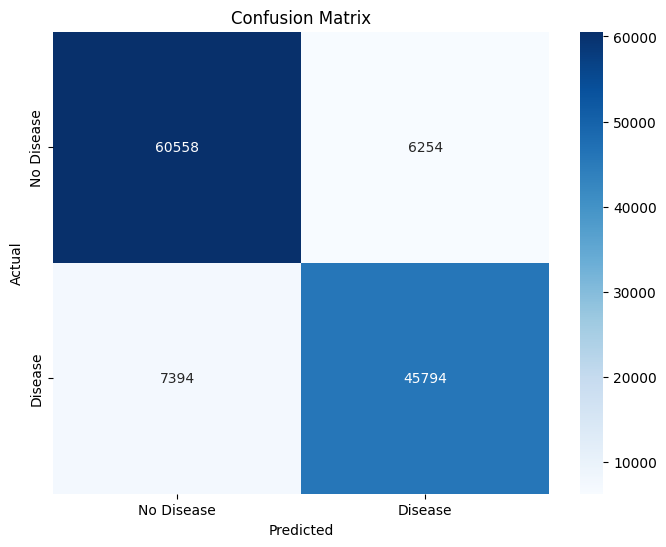

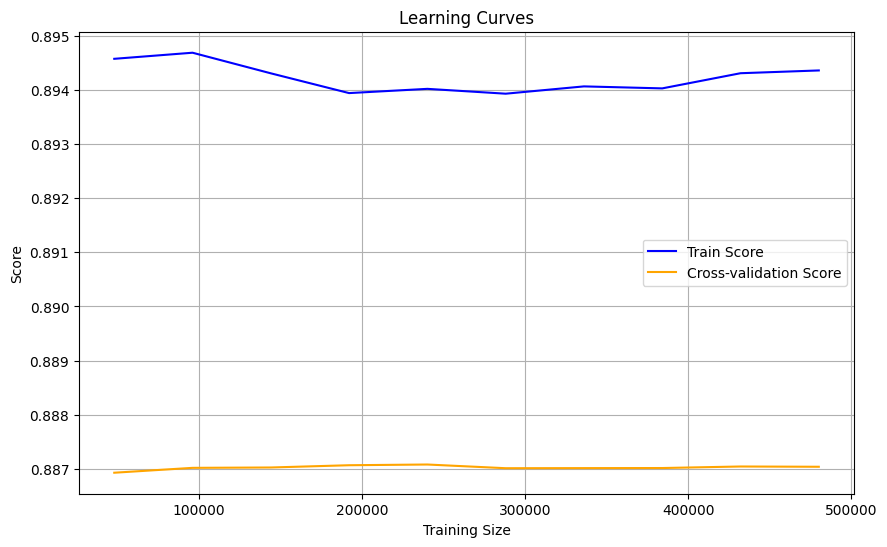

In [33]:
import pandas as pd
import numpy as np            # Ensure you have this import
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Проверка наличия пропущенных значений
print("Проверка на пропущенные значения:")
print(train_data.isnull().sum())

# 2. Определение признаков и целевой переменной
X = train_data.drop('class', axis=1)  # Предикторы
y = train_data['class']                 # Целевая переменная

# 3. Определение числовых и категориальных признаков
numeric_features = ['age', 'resting_blood_pressure', 'serum_cholestoral', 
                   'fasting_blood_sugar', 'maximum_heart_rate_achieved', 
                   'oldpeak', 'number_of_major_vessels']
categorical_features = ['sex', 'chest', 'resting_electrocardiographic_results', 
                        'exercise_induced_angina', 'slope', 'thal']

# 4. Создание преобразователя для нормализации и кодирования
numeric_transformer = StandardScaler()  # Нормализация
categorical_transformer = OneHotEncoder(handle_unknown='ignore')  # Кодирование с игнорированием неизвестных категорий

# 5. Построение колонного трансформера
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Создание пайплайна с предобработкой и логистической регрессией
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(C=1.0, random_state=42))  # Параметр C можно изменить по желанию
])

# 7. Разделение данных на обучающие и валидационные наборы
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Обучение модели
pipeline.fit(X_train, y_train)

# 9. Оценка модели
y_pred = pipeline.predict(X_val)
print(classification_report(y_val, y_pred))

# 10. Матрица ошибок
conf_matrix = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 11. Построение кривых обучения
train_sizes, train_scores, test_scores = learning_curve(pipeline, X, y, cv=5, n_jobs=-1,
                                                          train_sizes=np.linspace(0.1, 1.0, 10))

# Расчет средних значений
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Train Score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation Score', color='orange')
plt.title('Learning Curves')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid()
plt.show()

Основные показатели
Precision (Точность):

Для класса 0: 0.89 — из всех предсказаний, сделанных моделью для класса 0, 89% были верными. Это означает, что модель хорошо справляется с идентификацией здоровых пациентов.
Для класса 1: 0.88 — из всех предсказаний, сделанных моделью для класса 1, 88% были верными. Это также высокая точность, указывающая на то, что большинство пациентов, которых модель классифицирует как больных, действительно имеют заболевание.
Recall (Полнота):

Для класса 0: 0.91 — модель правильно распознаёт 91% всех настоящих пациентов без заболевания. Это хороший показатель, указывающий на низкий уровень ложных отрицательных срабатываний.
Для класса 1: 0.86 — 86% из всех настоящих больных пациентов правильно классифицируются как класс 1. Есть небольшая возможность для улучшения, так как это может означать наличие ложных отрицательных срабатываний.
F1-Score:

Для класса 0: 0.90 — это среднее гармоническое между точностью и полнотой для класса 0.
Для класса 1: 0.87 — аналогично, это показатель для класса 1. Значение F1-Score также высокие, что указывает на сбалансированную производительность.
Общая точность (Accuracy): 0.89 — модель правдиво классифицировала 89% всех примеров в валидационном наборе. Это очень хороший уровень точности.

Macro Avg и Weighted Avg:
Macro Avg: Средние значения для всех классов (оба класса рассматриваются одинаково). Они показывают, что в среднем модель работает хорошо для обоих классов.
Weighted Avg: Учитывает количество примеров в каждом классе и может предоставить более реалистичную картину производительности, учитывая дисбаланс классов (например, если классы 0 и 1 не равны по количеству).

Выводы
Хорошая производительность: Модель демонстрирует высокую точность, полноту и F1-оценку для обоих классов, что указывает на то, что она успешно справляется с задачей классификации.

Баланс между классами: Учитывая, что точность и полнота близки друг к другу для обоих классов, модель неплохо справляется с предотвращением ложноположительных и ложноотрицательных срабатываний.

Возможность для улучшения: Хотя модель показывает хорошие результаты в целом, незначительное снижение полноты для класса 1 (больные) может быть признаком того, что есть возможность для улучшения. Это может быть достигнуто например, с помощью других моделей (таких как Random Forest или SVM), валидации параметров модели логистической регрессии или рекалибровки модели.

2. Случайный лес

In [7]:
pip install scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
print("Размер обучающего набора:", X_train.shape)
print("Размер валидационного набора:", X_val.shape)

Размер обучающего набора: (480000, 14)
Размер валидационного набора: (120000, 14)


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     66812
           1       0.89      0.85      0.87     53188

    accuracy                           0.89    120000
   macro avg       0.89      0.88      0.88    120000
weighted avg       0.89      0.89      0.89    120000



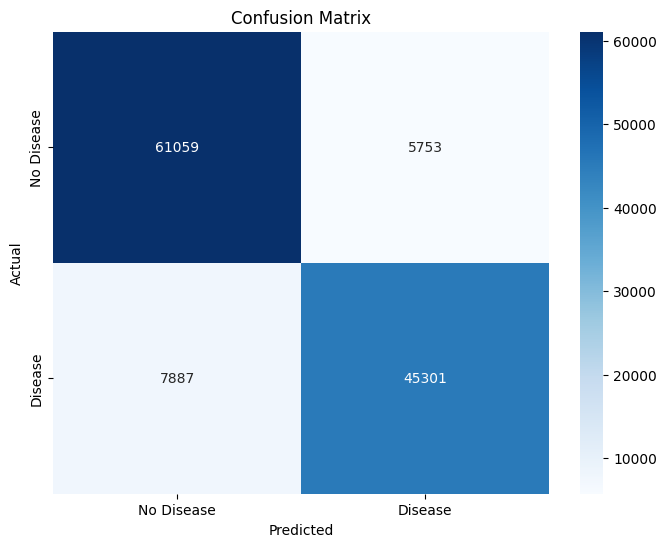

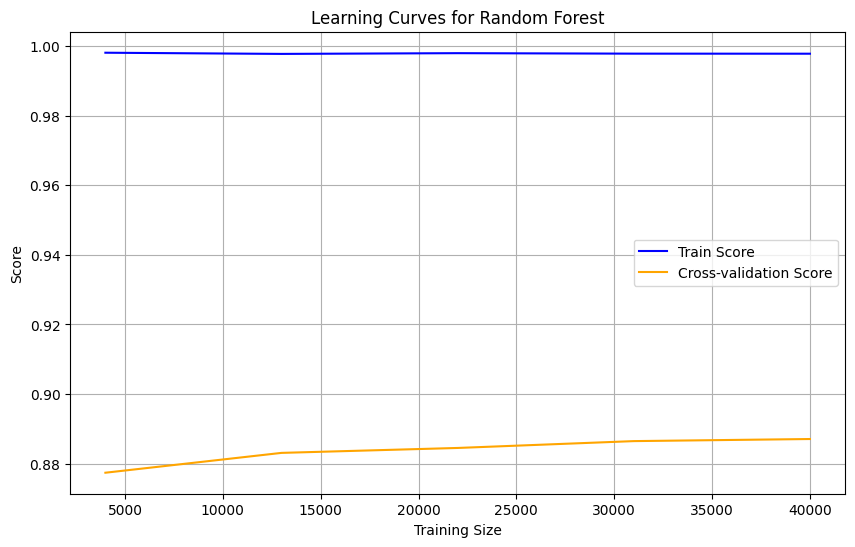

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Случайная выборка 10% данных для тестирования
X_train_sample = X_train.sample(frac=0.1, random_state=42)
y_train_sample = y_train[X_train_sample.index]  # Соответствующие метки

# Определение числовых и категориальных признаков
numeric_features = ['age', 'resting_blood_pressure', 'serum_cholestoral',
                   'fasting_blood_sugar', 'maximum_heart_rate_achieved', 
                   'oldpeak', 'number_of_major_vessels']
categorical_features = ['sex', 'chest', 'resting_electrocardiographic_results',
                        'exercise_induced_angina', 'slope', 'thal']

# Создание преобразователя для нормализации и кодирования
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Построение колонного трансформера
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Модель Случайный лес
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1))
])

# Обучение модели случайного леса
rf_model.fit(X_train_sample, y_train_sample)

# Оценка модели случайного леса
y_pred_rf = rf_model.predict(X_val)
print("Random Forest Classification Report:")
print(classification_report(y_val, y_pred_rf))

# 10. Матрица ошибок
conf_matrix = confusion_matrix(y_val, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Disease", "Disease"], 
            yticklabels=["No Disease", "Disease"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 11. Построение кривых обучения
# Используем выборку данных для обучения
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=0.1, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    rf_model, 
    X_sample, 
    y_sample, 
    cv=3,  # уменьшили количество фолдов
    n_jobs=1, 
    train_sizes=np.linspace(0.1, 1.0, 5)  # уменьшили количество точек
)

# Расчет средних значений
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Train Score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation Score', color='orange')
plt.title('Learning Curves for Random Forest')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid()
plt.show()

Основные показатели

Precision (Точность):
Для класса 0: 0.89 — среди всех предсказаний, сделанных моделью для класса 0, 89% оказались верными. Это значит, что модель уверенно определяет здоровых пациентов.
Для класса 1: 0.89 — из всех предсказаний, сделанных моделью для класса 1,89% также оказались верными. Это свидетельствует о хорошей точности в диагностировании больных.

Recall (Полнота):
Для класса 0: 0.91 — модель правильно классифицирует 91% всех здоровых пациентов. Высокий показатель, показывающий, что модель хорошо распознает людей без заболевания.
Для класса 1: 0.85 — модель правильно классифицирует 85% всех пациентов с заболеванием. Это немного ниже по сравнению с классом 0, что может означать, что некоторые больные пациенты не были распознаны, т.е., присутствуют ложные отрицательные срабатывания.

F1-Score:
Для класса 0: 0.90 — это среднее гармоническое между точностью и полнотой для класса 0.
Для класса 1: 0.87 — аналогичный показатель для класса 1. Значения F1-Score высокие, указывая на сбалансированную производительность модели.
Общая точность (Accuracy): 0.89 — модель правильно классифицировала 89% всех примеров в валидационном наборе. Данный уровень точности считается хорошим в большинстве приложений.

Macro Avg и Weighted Avg:
Macro Avg (Среднее): Это средние значения для всех классов (оба класса рассматриваются одинаково). Показатели 0.89 для точности и 0.88 для полноты показывают, что в среднем модель работает хорошо для обоих классов.
Weighted Avg (Взвешенное среднее): Учитывает количество примеров в каждом классе. Значения по этой метрике близки к макро-средним, что говорит о хорошей сбалансированности всех классов в наборе данных.

Выводы
Хорошая производительность: В целом, модель случайного леса демонстрирует хорошую точность и высокую полноту, что указывает на способность хорошо справляться с задачей классификации.

Зависимость от класса: Полнота для класса 1 немного ниже, что может считаться проблемой в задачах, где важно минимизировать ложные отрицательные результаты. Это критично в медицине, где пропуск больного пациента может привести к серьезным последствиям.

3. Нейронная сеть

c:\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8854 - loss: 0.2843 - val_accuracy: 0.8871 - val_loss: 0.2711
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8956 - loss: 0.2534 - val_accuracy: 0.8906 - val_loss: 0.2643
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9042 - loss: 0.2365 - val_accuracy: 0.8904 - val_loss: 0.2645
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9111 - loss: 0.2194 - val_accuracy: 0.8902 - val_loss: 0.2648
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9145 - loss: 0.2097 - val_accuracy: 0.8873 - val_loss: 0.2706
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9172 - loss: 0.2055 - val_accuracy: 0.8909 - val_loss: 0.2632
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9173 - loss: 0.2029 - val_accuracy: 0.8877 - val_loss: 0.2698
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9186 -

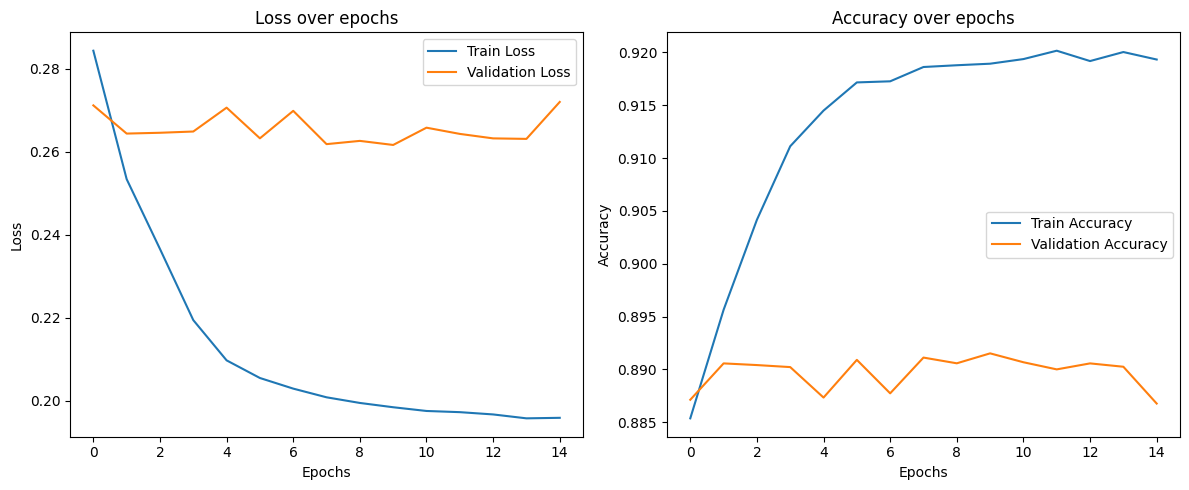

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

# Разделение данных на обучающие и валидационные наборы
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Случайная выборка 10% данных для обучения
X_train_sample = X_train.sample(frac=0.1, random_state=42)
y_train_sample = y_train[X_train_sample.index]

# Определение числовых и категориальных признаков
numeric_features = ['age', 'resting_blood_pressure', 'serum_cholestoral',
                   'fasting_blood_sugar', 'maximum_heart_rate_achieved', 
                   'oldpeak', 'number_of_major_vessels']
categorical_features = ['sex', 'chest', 'resting_electrocardiographic_results',
                        'exercise_induced_angina', 'slope', 'thal']

# Преобразователь для нормализации и кодирования
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Построение колонного трансформера
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Подготовка данных
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Преобразование данных
X_train_transformed = pipeline.fit_transform(X_train_sample)
X_val_transformed = pipeline.transform(X_val)

# Построение нейронной сети
nn_model = Sequential()
nn_model.add(Dense(32, activation='relu', input_shape=(X_train_transformed.shape[1],)))
nn_model.add(Dense(16, activation='relu'))
nn_model.add(Dense(1, activation='sigmoid'))  # Для двоичной классификации

# Компиляция модели
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Использование EarlyStopping для предотвращения переобучения
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Обучение нейронной сети и сохранение истории
history = nn_model.fit(X_train_transformed, y_train_sample, epochs=50, batch_size=32, 
             validation_data=(X_val_transformed, y_val), 
             callbacks=[early_stopping])

# Оценка нейронной сети
loss, accuracy = nn_model.evaluate(X_val_transformed, y_val)
print(f"Neural Network Accuracy: {accuracy:.2f}")

# График потерь и точности
plt.figure(figsize=(12, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import classification_report
import numpy as np

# Получаем вероятности предсказаний на валидационном наборе
y_pred_prob = nn_model.predict(X_val_transformed)

# Преобразуем вероятности в классы (используем порог 0.5)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Вычисляем и выводим отчет о классификации
print(classification_report(y_val, y_pred))

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     66812
           1       0.89      0.85      0.87     53188

    accuracy                           0.89    120000
   macro avg       0.89      0.89      0.89    120000
weighted avg       0.89      0.89      0.89    120000



In [24]:
# Сохранение модели
nn_model.save('my_neural_network_model.keras')
print("Модель успешно сохранена.")

Модель успешно сохранена.


Precision (Точность):
Класс 0 (здоровые пациенты): 89% из всех предсказаний для этого класса были верными. Это свидетельствует о том, что нейронная сеть хорошо определяет здоровых пациентов.
Класс 1 (больные пациенты): 88% верных классификаций для класс 1 также указывает на высокое качество работы нейронной сети.

Recall (Полнота):
Класс 0: 90% реальных здоровых пациентов были правильно классифицированы. Это хороший показатель, так как он показывает низкое количество ложных отрицательных срабатываний.
Класс 1: 86% настоящих больных пациентов были правильно классифицированы, но существует возможность повышения этого показателя.

F1-Score:
Класс 0: F1-Score равен 0.90, что свидетельствует о хорошем балансе между точностью и полнотой.
Класс 1: F1-Score равен 0.87. Хотя это тоже хороший результат, он показывает, что можно улучшить производительность для класса 1.

Accuracy (Общая точность):
Общая точность модели составила 89%. Это хороший уровень, указывающий на то, что большинство предсказаний были верными.

Macro Avg и Weighted Avg:
Macro Avg: Это средние значения для всех классов, которые показывают стабильную работу модели в среднем по всем классам.
Weighted Avg: Учитывает количество примеров в каждом классе и показывает, что модель обладает хорошим балансом.

Выводы:
Нейронная сеть демонстрирует высокую производительность с хорошими показателями точности и полноты.
Хотя она показывает перспективные результаты, есть небольшой потенциал для улучшения, особенно для класса 1, где достигнуто 86% полноты. Это можно попробовать исправить при оптимизации гиперпараметров или адаптации модели.

Сравнение моделей

Точность (Precision):
Все три модели показывают хорошие результаты, но случайный лес имеет легкое преимущество в точности для класса 1 (0.89).

Полнота (Recall):
Логистическая регрессия показывает наилучший результат для класса 0 (91%), что позволяет снизить количество ложных отрицательных срабатываний. Полнота для класса 1 у всех моделей практически на одном уровне, однако логистическая регрессия немного лучше.

F1-Score:
Все модели показывают схожие значения F1-Score для обоих классов, что указывает на то, что каждая модель сбалансирована в своих предсказаниях.

Общая точность (Accuracy):
Все три модели имеют одинаковую общую точность (0.89), что говорит о том, что они в целом хорошо справляются с задачей.

Заключение: 
Все три модели (логистическая регрессия, случайный лес и нейронная сеть) показывают высокий уровень производительности и подходящие результаты для данной задачи классификации.
Выбор модели может зависеть от предпочтений: логистическая регрессия хорошо интерпретируема, случайный лес показывает немного лучшую производительность и общую точность, тогда как нейронная сеть может предложить мощные возможности, если потребуются дополнительные настройки и мощность.

Для инференса можно выбрать нейронную сеть. Хотя она требует большего объема вычислений и дополнительных настроек, она может превосходить другие модели при работе с большими или сложными наборами данных.

Загрузка лучших весов выбранной модели и подготовка скрипта для инференса

In [25]:
import pandas as pd
from keras.models import load_model
import joblib

# Загружаем модель
model = load_model('my_neural_network_model.keras')
print("Модель успешно загружена.")

# Подготавливаем новые данные без столбца ID
new_data = pd.DataFrame({
    'age': [60],
    'sex': [1],
    'chest': [2],
    'resting_blood_pressure': [130],
    'serum_cholestoral': [250],
    'fasting_blood_sugar': [0],
    'resting_electrocardiographic_results': [1],
    'maximum_heart_rate_achieved': [150],
    'exercise_induced_angina': [0],
    'oldpeak': [2.5],
    'slope': [2],
    'number_of_major_vessels': [0],
    'thal': [3]
})

# Обработка новых данных через ваш Pipeline
new_data_transformed = pipeline.transform(new_data)

# Проверка количества признаков
print("Количество признаков после предобработки новых данных:", new_data_transformed.shape[1])

# Делаем предсказания
predictions = model.predict(new_data_transformed)
predicted_classes = (predictions > 0.5).astype("int32")
print("Предсказанные классы:", predicted_classes)


Модель успешно загружена.
Количество признаков после предобработки новых данных: 5542
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Предсказанные классы: [[0]]
